In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('/content/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
df.iloc[:,1:]

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [9]:
import matplotlib.pyplot as plt


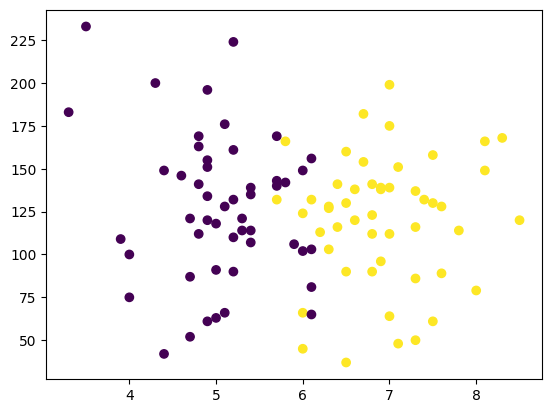

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [16]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [17]:
x


,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [18]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [22]:
x_train

,Unnamed: 0,cgpa
89,89,4.9
57,57,6.5
39,39,4.6
76,76,4.9
1,1,5.9
...,...,...
11,11,6.9
60,60,6.9
49,49,5.4
50,50,3.5


In [23]:
y_train

,placement
89,0
57,1
39,0
76,0
1,0
...,...
11,1
60,1
49,0
50,0


In [24]:
x_test

,Unnamed: 0,cgpa
8,8,6.1
82,82,6.5
86,86,5.1
65,65,8.1
0,0,6.8
51,51,4.8
77,77,7.3
71,71,6.1
90,90,7.3
81,81,5.4


In [25]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [26]:
x_train=sc.fit_transform(x_train)


In [27]:
x_test=sc.transform(x_test)

In [28]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [29]:
lr.fit(x_train,y_train)

LogisticRegression()

In [35]:
y_pred=lr.predict(x_test)

In [36]:
y_test

,placement
8,0
82,1
86,0
65,1
0,1
51,0
77,1
71,1
90,1
81,0


In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(y_test,y_pred)

0.95

In [41]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

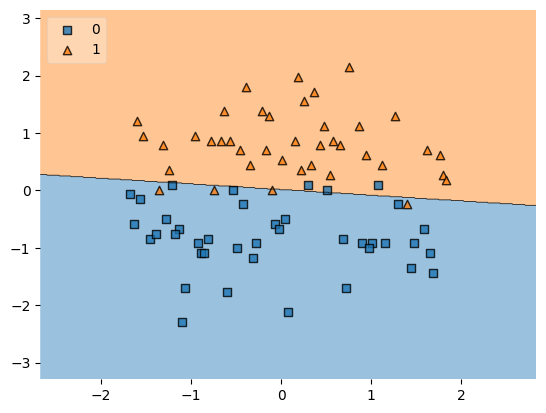

In [45]:
plot_decision_regions(x_train,y_train.values,clf=lr,legend=2)

In [46]:
import pickle

In [47]:
pickle.dump(lr,open('model.pkl','wb'))